# Lab 8 : Star Formation 

In [31]:
import numpy as np
from astropy import units as u
from astropy import constants as const

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Part A

Create a function that returns the SFR for a given luminosity (NUV, FUV, TIR, Halpha)

$Log( {\rm SFR} (M_\odot/year)) = Log(Lx (erg/s)) - Log(Cx)$ 

Including corrections for dust absorption 

Kennicutt & Evans 2012 ARA&A Equation 12 and Table 1, 2

In [18]:
def StarFormationRate(L, Type, TIR=0):
    '''
    Description: Function to compute the star formation rate of a galaxy following
    Kennicut & Evans 2012 Eq12 (ARA&A 50)
    
    Inputs:
        - L: float, luminosity of galaxy in erg/s (nonastropy entitity)
        - Type: string, wavelength observed ('FUV', 'NUV', 'TIR', 'Halpha')
        - TIR: float, total infrared luminosityty in erg/s, to be used for dust correction (default = 0)
        
    Returns:
        - LogSFR: float, log of the star formation rate in Msun/yr
    '''
    
    # Acquiring Correctional Factors #
    if (Type == 'FUV'):
        logCx = 43.35 # calibration constant from L(FUV) to SFR
        TIRc = 0.46 # dust absorbption correction term
    elif (Type == 'NUV'):
        LogCx = 43.17 # calibration constant from L(NUV) to SFR
        TIRc = 0.27 # dust absorbption correction term
    elif (Type == 'Halpha'):
        Logcx = 41.27 # calibration constant from L(Halpha) to SFR
        TIRc = 0.0024 # dust absorbption correction term
    elif (Type == 'TIR'):
        LogCx =  43.41 # calibration constant from L(TIR) to SFR
        TIRc = 0 # dust absorbption correction term
    else:
        print('Non-compatable wavelength range. Please select one of the following options: \n FUV, NUV, Halpha, or TIR')
        return
        
        
    ''' Note: This function could be made more pythonic with the use of a dictionary 
    storing all of these correction factors, and referenicing it accordingly
    
    example: 
    
    1 Corrections = {'FUV': [43.35, 0.46], ...}
    2 
    3 if Type in Correction:
    4     [LogCx, TIRc] = Corrections[Type]
    5 else:
    6     print('Non-compatable wavelength range. Please select one of the following options: \n FUV, NUV, Halpha, or TIR')
    '''
    
    
    # Correct the luminosiy for the dust using the TIR #
    Lcorr = L + (TIRc * TIR)
    
    # Star Formation Rate #
    LogSFR = np.log10(Lcorr) - LogCx
    
    return LogSFR
### END StarFormationRate

Let's try to reproduce SFRs derived for the WLM Dwarf Irregular Galaxy using UV luminosities measured with Galex. 

Compare results to Table 1 from Lee et al. 2009 (who used the older Kennicutt 98 methods)
https://ui.adsabs.harvard.edu/abs/2009ApJ...706..599L/abstract

We will use galaxy properties from NED (Photometry and SED):
https://ned.ipac.caltech.edu/

In [19]:
# First need the Luminosity of the Sun in the right units
L_sun = const.L_sun.to(u.erg / u.s).value # Solar Luminosity in erg/s

In [20]:
#  WLM Dwarf Irregular Galaxy
NUV_WLM = 1.71e7 * L_sun # From NED GALEX data
TIR_WLM = (2.48e6 * L_sun) + (3.21e5 * L_sun) + (2.49e6 * L_sun) # Combination of NIR, MIR, FIR

In [21]:
# Testing... #
StarFormationRate(NUV_WLM, 'NUV', TIR_WLM)
StarFormationRate(1e6*L_sun, 'blah', 5e6*L_sun)

Non-compatable wavelength range. Please select one of the following options: 
 FUV, NUV, Halpha, or TIR


# Part B Star formation main sequence

1) Write a function that returns the average SFR of a galaxy at a given redshift, given its stellar mass

2) What is the average SFR of a MW mass galaxy today? at z=1?

3) Plot the SFR main sequence for a few different redshifts from 1e9 to 1e12 Msun.


From Whitaker 2012:

log(SFR) = $\alpha(z)({\rm log}M_\ast - 10.5) + \beta(z)$

$\alpha(z) = 0.7 - 0.13z$

$\beta(z) = 0.38 + 1.14z - 0.19z^2$

# Step 1

In [25]:
def StarFormationRateMainSequence(Mstar, z):
    ''' 
    Description: Function sed to compute the averafe SFR of a galaxy as a 
    function fo stellar mass and redshift
    
    Inputs: 
        - Mstar = float, stellar mass fo galaxy in Msun 
        - z: float, redshift 
        
    Returns:
         - LogSFR = float, log of the star formation rate in Msun/yr
    '''
    
    # Redshift Correction Factors #
    a = 0.7 - (0.13 * z)
    b = 0.38 + (1.14 * z) - (0.19 * (z ** 2))
    
    # Star Formation Rate #
    LogSFR = (a * (np.log10(Mstar) - 10.5)) + b
    
    return LogSFR
### END StarFormationRate_MainSequencef

# Step 2

In [26]:
# MW stellar mass disk at z=0
MWmstar = 7.5e10

In [28]:
# SFR for a MW type galaxy
print(StarFormationRateMainSequence(MWmstar, 0))
print(10** StarFormationRateMainSequence(MWmstar, 0))

0.64254288437419
4.390792203431891


In [29]:
# MW at z = 1
print(StarFormationRateMainSequence(MWmstar, 1))
print(10** StarFormationRateMainSequence(MWmstar, 1))

1.5437849201332692
34.97719031976979


# Step 3

In [34]:
# create an array of stellar masses
Mass = np.linspace(1e8, 1e12)

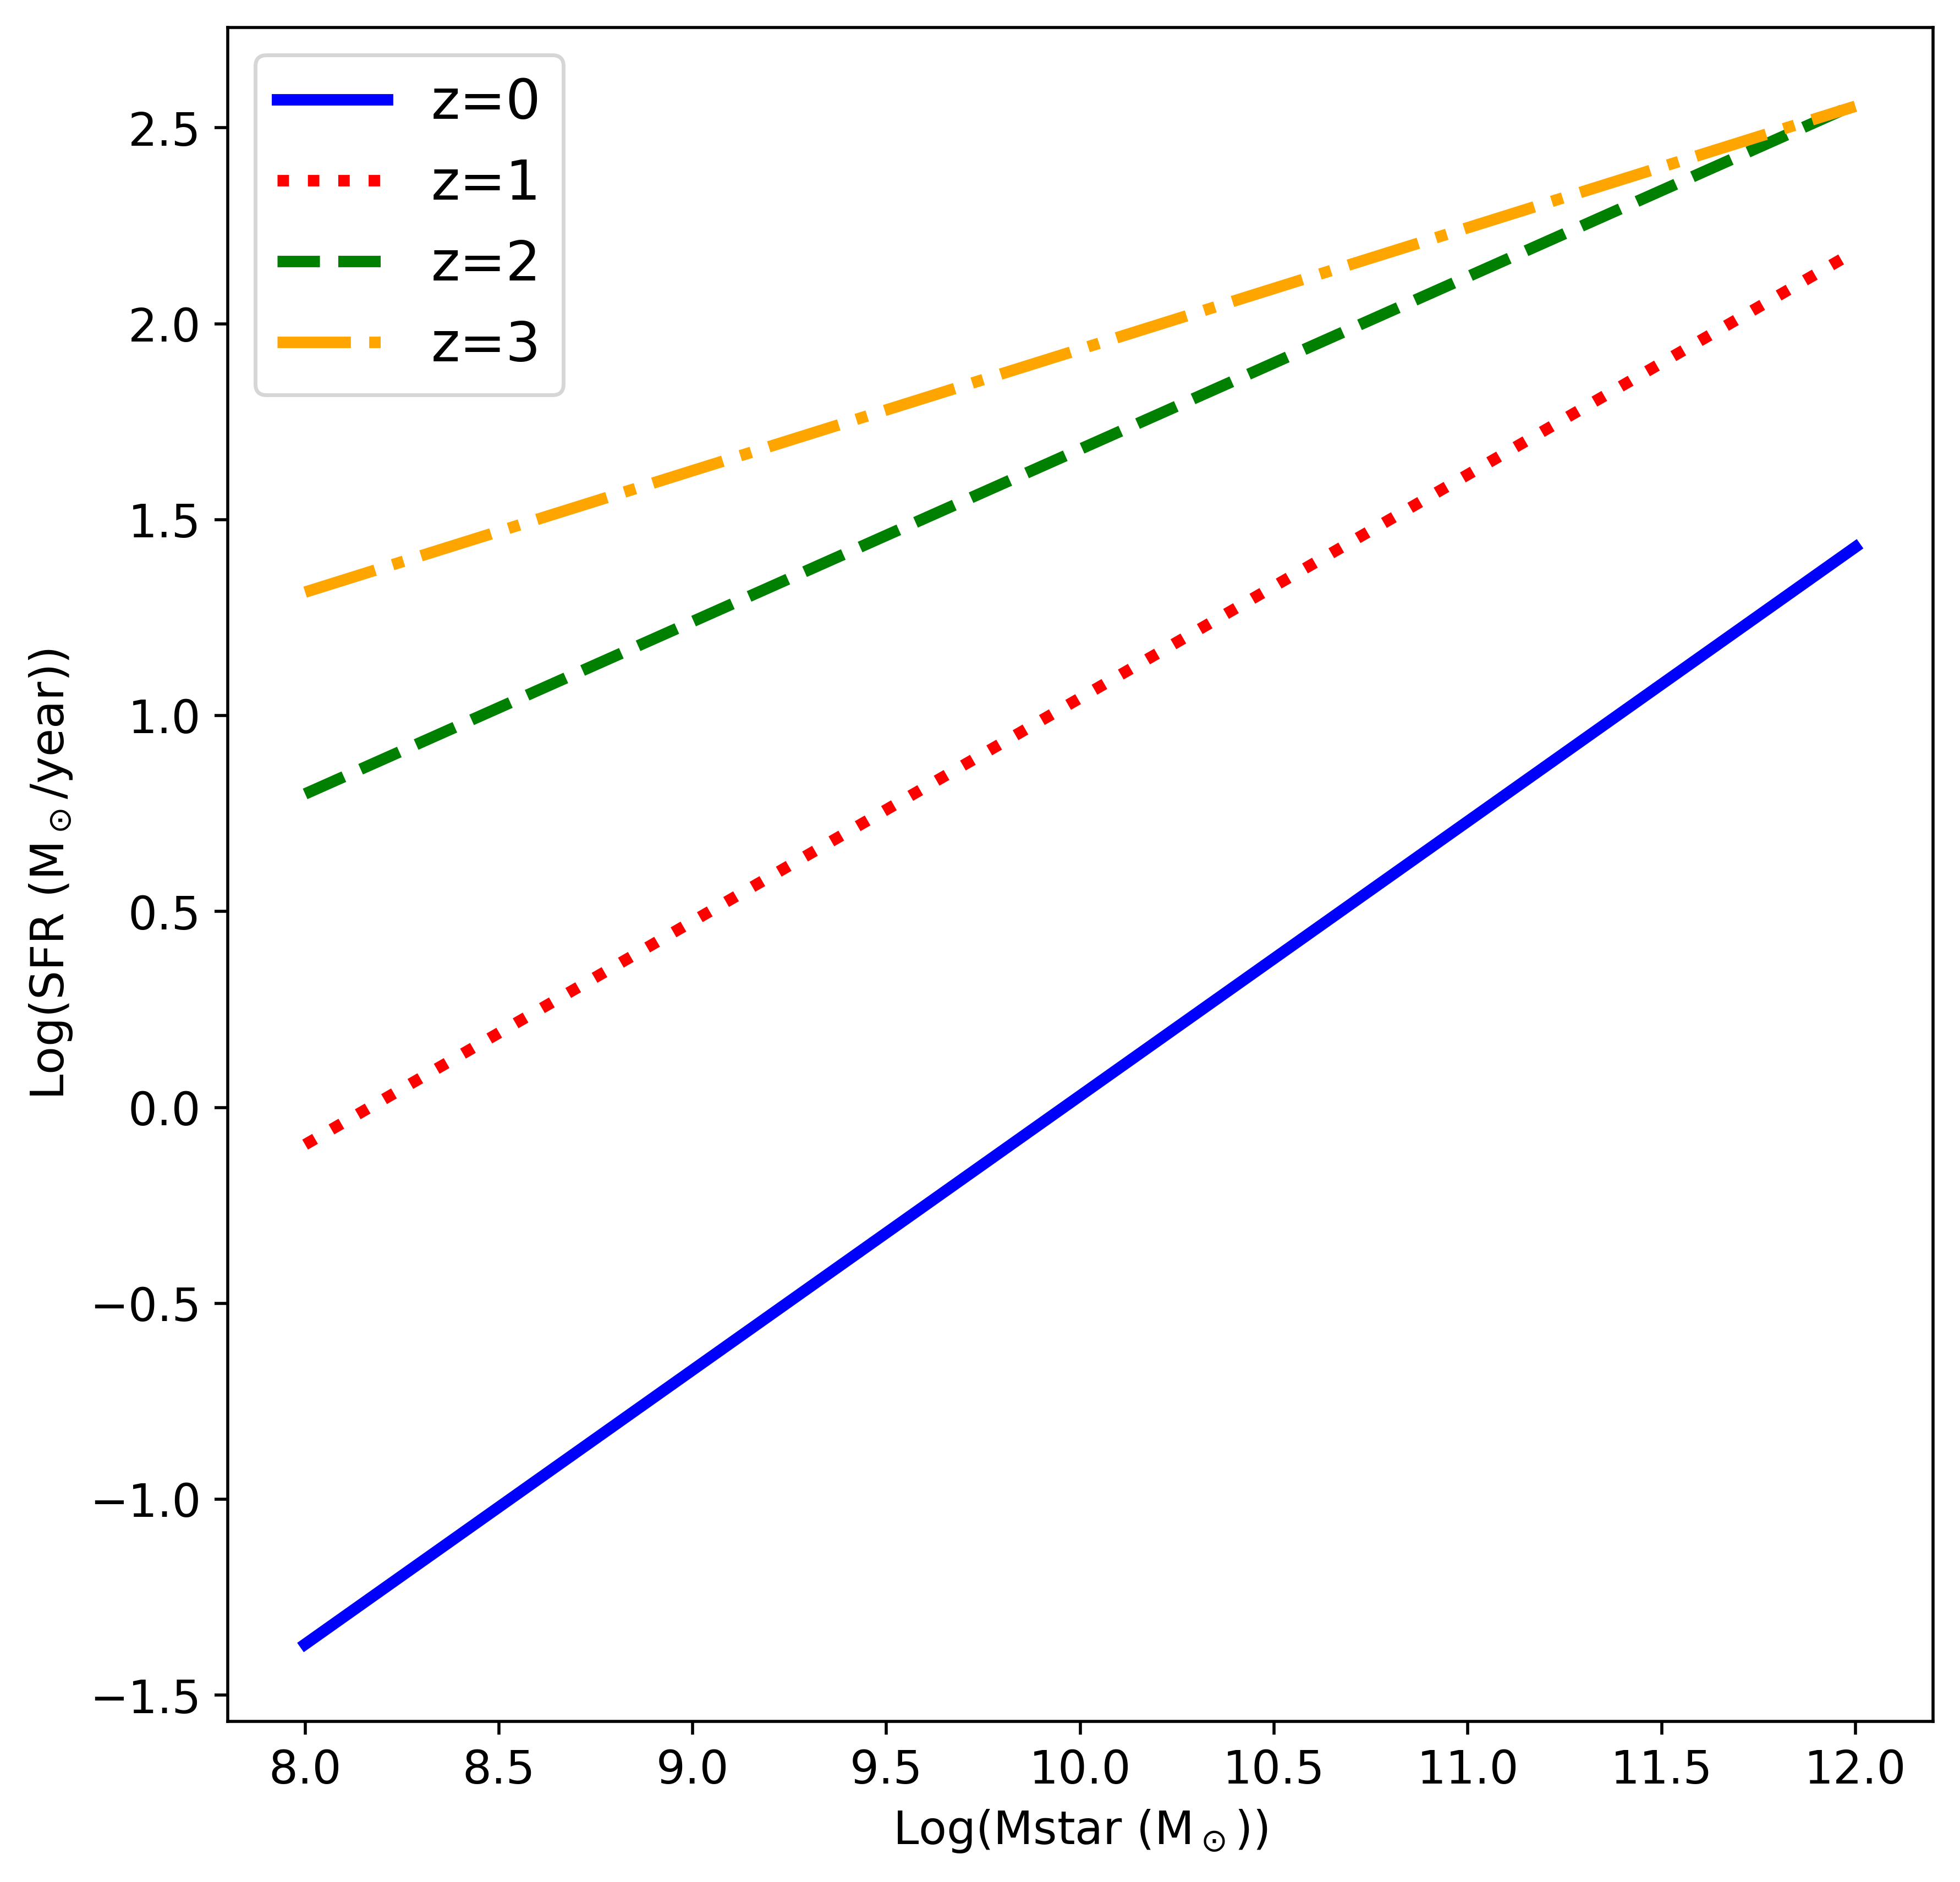

In [39]:

fig = plt.figure(figsize=(8,8), dpi=500)
ax = plt.subplot(111)

# add log log plots
plt.plot(np.log10(Mass), StarFormationRateMainSequence(Mass, 0), color = 'blue', linewidth=3, label = 'z=0')
plt.plot(np.log10(Mass), StarFormationRateMainSequence(Mass, 1), color = 'red', linestyle = ':', linewidth=3, label = 'z=1')
plt.plot(np.log10(Mass), StarFormationRateMainSequence(Mass, 2), color = 'green', linestyle = '--', linewidth=3, label = 'z=2')
plt.plot(np.log10(Mass), StarFormationRateMainSequence(Mass, 3), color = 'orange', linestyle = '-.', linewidth=3, label = 'z=3')


# Add axis labels
plt.xlabel('Log(Mstar (M$_\odot$))', fontsize=12)
plt.ylabel('Log(SFR (M$_\odot$/year))', fontsize=12)


#adjust tick label font size
label_size = 12
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size

# add a legend with some customizations.
legend = ax.legend(loc='upper left',fontsize='x-large')


# Save file
plt.savefig('Lab8_SFR_MainSequence.png')


# Part C  Starbursts

Use your `StarFormationRate` code to determine the typical star formation rates for the following systems with the listed Total Infrared Luminosities (TIR): 

Normal Galaxies: $10^{10}$ L$_\odot$

LIRG: $10^{11}$ L$_\odot$

ULIRG: $10^{12} $ L$_\odot$

HLIRG: $10^{13} $ L$_\odot$

In [48]:
# normal galaxies 
TIR_Normal = 1e10 * L_sun

print(10 ** StarFormationRate(TIR_Normal, 'TIR'))

1.4892648150381245


In [50]:
# LIRGs  
TIR_LIRG = 1e11 * L_sun

print(10 ** StarFormationRate(TIR_LIRG, 'TIR'))

14.892648150381245


In [51]:
# ULIRGs
TIR_ULIRG = 1e12 * L_sun

print(10 ** StarFormationRate(TIR_ULIRG, 'TIR'))

148.92648150381245


In [49]:
# HLIRGs
TIR_HLIRG = 1e13 * L_sun
print(10 ** StarFormationRate(TIR_HLIRG, 'TIR'))

1489.2648150381244
